# Mejoras del modelo de sentimiento

Este notebook compara modelos clásicos, ajusta hiperparámetros con validación cruzada y guarda el mejor pipeline.

In [9]:
import shutil
import subprocess

nvidia_smi = shutil.which('nvidia-smi')
# Check if GPU is available
if nvidia_smi:
    print(subprocess.run([nvidia_smi], capture_output=True, text=True, check=False).stdout)
else:
    print('No se encontro nvidia-smi; se usara CPU.')

Mon Sep  7 13:13:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.99                 Driver Version: 555.99         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   39C    P0             19W /   65W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
KAGGLE_DATASET = 'yasserh/imdb-movie-ratings-sentiment-analysis'
sns.set_theme(style='whitegrid')

## 1. Datos

In [2]:
reviews = pd.read_csv('cleaned_reviews.csv')

## 2. Separacion reproducible y modelos candidatos

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    reviews['text'], reviews['label'], test_size=0.2,
    random_state=RANDOM_STATE, stratify=reviews['label']
)

candidate_models = {
    'LinearSVC': Pipeline([
        ('tfidf', TfidfVectorizer(sublinear_tf=True)),
        ('classifier', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'LogisticRegression': Pipeline([
        ('tfidf', TfidfVectorizer(sublinear_tf=True)),
        ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'MultinomialNB': Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('classifier', MultinomialNB()),
    ]),
}

In [4]:
model_results = []
for model_name, model in candidate_models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    model_results.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, predictions),
        'f1_macro': f1_score(y_test, predictions, average='macro'),
    })

comparison = pd.DataFrame(model_results).sort_values('f1_macro', ascending=False)
comparison

,model,accuracy,f1_macro
0,LinearSVC,0.896161,0.896151
1,LogisticRegression,0.895154,0.895118
2,MultinomialNB,0.858402,0.858354


## 3. Ajuste de hiperparametros con validacion cruzada

In [5]:
search_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('classifier', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE)),
])
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [1, 2, 5],
    'tfidf__sublinear_tf': [True],
    'classifier__C': [0.5, 1.0, 2.0],
}

grid_search = GridSearchCV(
    search_pipeline, param_grid, scoring='f1_macro', cv=5,
    n_jobs=-1, verbose=1, return_train_score=False
)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print('Mejores parametros:', grid_search.best_params_)
print(f'Mejor F1 macro CV: {grid_search.best_score_:.3f}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Mejores parametros: {'classifier__C': 2.0, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}
Mejor F1 macro CV: 0.912


Accuracy en test: 0.916
              precision    recall  f1-score   support

    negative       0.93      0.90      0.92      3963
    positive       0.91      0.93      0.92      3982

    accuracy                           0.92      7945
   macro avg       0.92      0.92      0.92      7945
weighted avg       0.92      0.92      0.92      7945



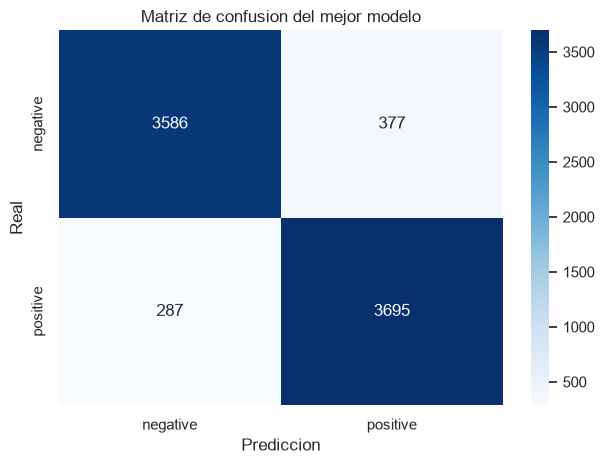

In [6]:
best_predictions = best_model.predict(X_test)
print(f'Accuracy en test: {accuracy_score(y_test, best_predictions):.3f}')
print(classification_report(y_test, best_predictions, labels=['negative', 'positive'], zero_division=0))

confusion = confusion_matrix(y_test, best_predictions, labels=['negative', 'positive'])
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.title('Matriz de confusion del mejor modelo')
plt.tight_layout()
plt.show()

## 4. Analisis de errores

In [7]:
error_analysis = pd.DataFrame({
    'text': X_test,
    'actual': y_test,
    'predicted': best_predictions,
})
errors = error_analysis[error_analysis['actual'] != error_analysis['predicted']]
print(f'Errores encontrados: {len(errors)} de {len(error_analysis)}')
errors.head(10)

Errores encontrados: 664 de 7945


,text,actual,predicted
14402,Shame on you if you give this film a low ratin...,positive,negative
11065,There is a really good movie lurking just bene...,negative,positive
19914,"""The Bank"" (1915, Chaplin) ""The Bank"" was one ...",negative,positive
29178,"Welcome to Our Town, welcome to your town? As ...",negative,positive
16644,"Compared to the acclaimed Hollywood remake, th...",positive,negative
32390,"A light-hearted comedy, Nothing shows us a wor...",positive,negative
25906,"The lovely Eva Longoria Parker plays Kate, who...",negative,positive
37415,"I do not recommend this movie , because it's i...",negative,positive
3020,Quote: theurgist: Anyone with an I.Q. over 50 ...,negative,positive
35896,"It's hard to use words for this movie, since i...",positive,negative


## 5. Guardar y reutilizar el mejor modelo

In [8]:
MODEL_PATH = Path('sentiment_model.joblib')
joblib.dump(best_model, MODEL_PATH)
print(f'Modelo guardado en: {MODEL_PATH.resolve()}')

loaded_model = joblib.load(MODEL_PATH)
examples = [
    'A wonderful movie with excellent performances.',
    'The story was boring and the acting was poor.',
]
pd.DataFrame({'review': examples, 'prediction': loaded_model.predict(examples)})

Modelo guardado en: C:\Users\rmerc\Documents\GitHub\sentiment-analysis-movies-reviews\sentiment_model.joblib


,review,prediction
0,A wonderful movie with excellent performances.,positive
1,The story was boring and the acting was poor.,negative


## Interpretación, comparación y limitaciones

La búsqueda seleccionó `LinearSVC` con `C=2.0`, bigramas `(1, 2)`, `min_df=1` y `sublinear_tf=True`. Obtuvo `0.916` de accuracy en test y F1 macro de validación cruzada `0.912`, una mejora pequeña frente al baseline de `0.915`.

Frente a `LogisticRegression`, `MultinomialNB` y DistilBERT, el modelo clásico es más rápido, consume menos memoria y es más fácil de desplegar. Todos los modelos TF-IDF comparten limitaciones con la ironía y el contexto largo. DistilBERT obtuvo aproximadamente `0.865` de accuracy/F1 macro en test.

Limitaciones: una sola partición, posibles errores de etiquetado, dominio cinematográfico y ausencia de intervalos de confianza. Conviene repetir con varias semillas y validación cruzada anidada.

## Conclusiones

El mejor modelo observado es `LinearSVC` optimizado con TF-IDF. Ofrece el mejor equilibrio entre rendimiento, coste y facilidad de despliegue.